### Importação dos dados



In [60]:
import pandas as pd
import matplotlib.pyplot as plt

url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja1 = pd.read_csv(url1)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja1.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


In [61]:
#criação de lista com as lojas
lista_lojas = [loja1, loja2, loja3, loja4]

#1. Análise do faturamento



In [62]:
print("Faturamento total por loja:\n")

for i in range(0,4):
  faturamento_loja = lista_lojas[i]['Preço'].sum()
  print(f"Loja {i+1}: R$ {faturamento_loja}")

Faturamento total por loja:

Loja 1: R$ 1534509.12
Loja 2: R$ 1488459.06
Loja 3: R$ 1464025.03
Loja 4: R$ 1384497.58


<function matplotlib.pyplot.show(close=None, block=None)>

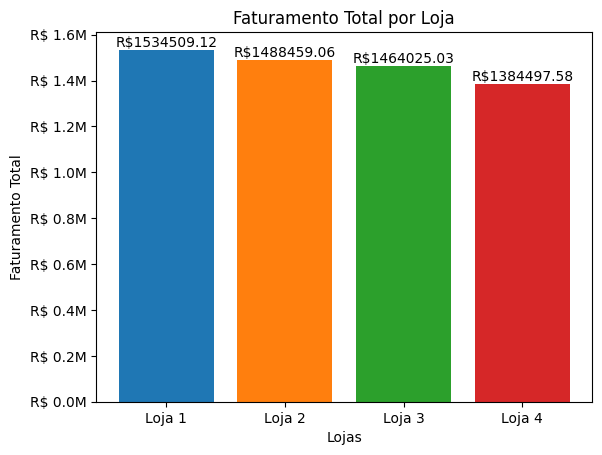

In [63]:
import matplotlib.ticker as mtick

cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

faturamentos = []
nomes_lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']
for i in range(0,4):
  faturamento_loja = lista_lojas[i]['Preço'].sum()
  faturamentos.append(faturamento_loja)

plt.figure()
plt.bar(nomes_lojas, faturamentos)
barras = plt.bar(nomes_lojas, faturamentos, color=cores)
plt.bar_label(barras, fmt='R$%.2f')
plt.title('Faturamento Total por Loja')
plt.xlabel('Lojas')
plt.ylabel('Faturamento Total')
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f'R$ {x/1_000_000:.1f}M')
)
plt.show

# 2. Vendas por Categoria

In [64]:
print("Vendas por Categoria:\n")

for i in range(0,4):
  vendas_por_categoria = lista_lojas[i].groupby('Categoria do Produto').size().sort_values(ascending=False)
  print(f"Loja {i+1}:\n{vendas_por_categoria}\n")

Vendas por Categoria:

Loja 1:
Categoria do Produto
moveis                   465
eletronicos              448
brinquedos               324
eletrodomesticos         312
esporte e lazer          284
instrumentos musicais    182
livros                   173
utilidades domesticas    171
dtype: int64

Loja 2:
Categoria do Produto
moveis                   442
eletronicos              422
brinquedos               313
eletrodomesticos         305
esporte e lazer          275
instrumentos musicais    224
livros                   197
utilidades domesticas    181
dtype: int64

Loja 3:
Categoria do Produto
moveis                   499
eletronicos              451
brinquedos               315
eletrodomesticos         278
esporte e lazer          277
livros                   185
instrumentos musicais    177
utilidades domesticas    177
dtype: int64

Loja 4:
Categoria do Produto
moveis                   480
eletronicos              451
brinquedos               338
esporte e lazer          277
eletrod

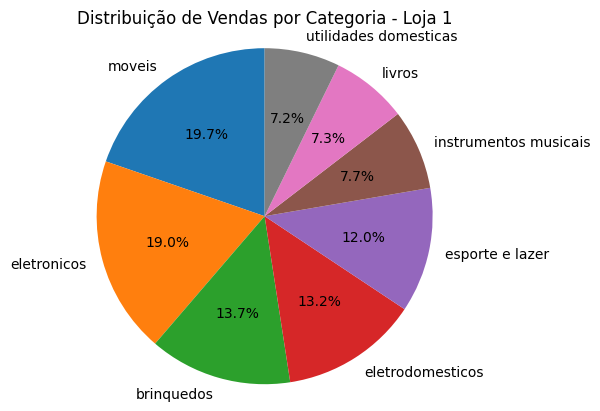

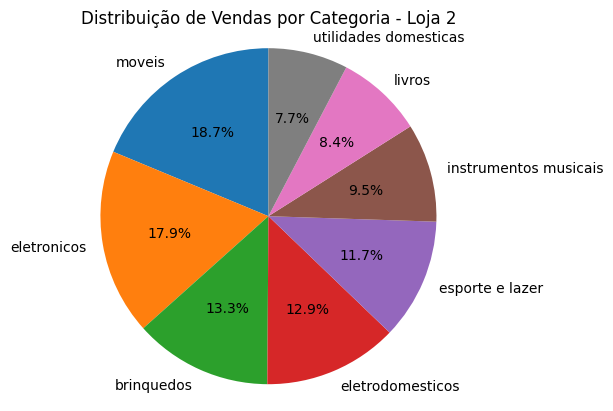

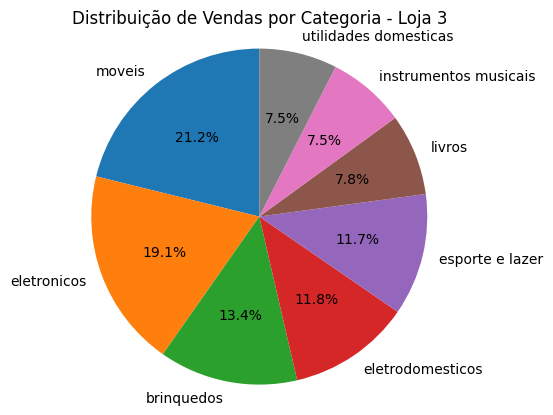

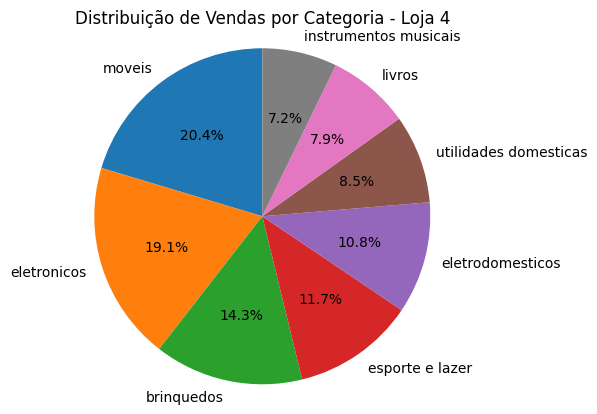

In [65]:
for i in range(0,4):
  vendas_por_categoria = lista_lojas[i].groupby('Categoria do Produto').size().sort_values(ascending=False)

  plt.figure()

  plt.pie(
      vendas_por_categoria,
      labels=vendas_por_categoria.index,
      autopct='%1.1f%%',
      startangle=90
  )

  plt.title(f"Distribuição de Vendas por Categoria - Loja {i+1}")
  plt.axis('equal')
  plt.show()

# 3. Média de Avaliação das Lojas


In [66]:
print("Média de avaliações para cada loja:\n")

for i in range(0,4):
  media_avaliacoes = lista_lojas[i]['Avaliação da compra'].mean()
  print(f"Loja {i+1}: {media_avaliacoes:.2f}")

Média de avaliações para cada loja:

Loja 1: 3.98
Loja 2: 4.04
Loja 3: 4.05
Loja 4: 4.00


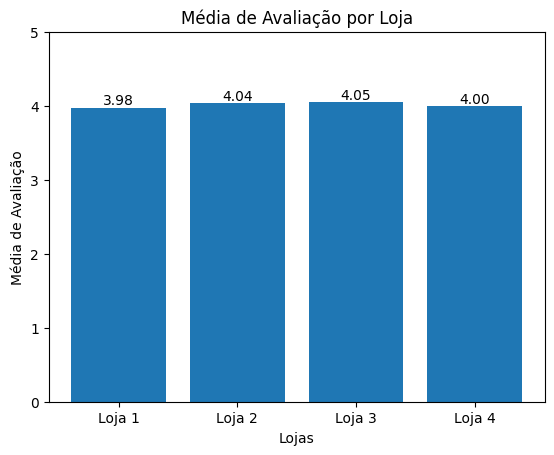

In [67]:
medias_avaliacoes = []
nomes_lojas = []

for i in range(0,4):
    media_avaliacoes = lista_lojas[i]['Avaliação da compra'].mean()
    medias_avaliacoes.append(media_avaliacoes)
    nomes_lojas.append(f"Loja {i+1}")

plt.figure()
barras = plt.bar(nomes_lojas, medias_avaliacoes)
plt.bar_label(barras, fmt='%.2f')
plt.ylabel("Média de Avaliação")
plt.xlabel("Lojas")
plt.title("Média de Avaliação por Loja")

plt.ylim(0, 5)
plt.show()

# 4. Produtos Mais e Menos Vendidos

In [68]:
for i in range(0,4):
  produtos_vendidos = lista_lojas[i]['Produto'].value_counts()
  print(f"Produtos mais vendidos da loja {i+1}:\n{produtos_vendidos.head()}\n")
  print(f"Produtos menos vendidos da loja {i+1}:\n{produtos_vendidos.tail()}\n")

Produtos mais vendidos da loja 1:
Produto
Micro-ondas           60
TV Led UHD 4K         60
Guarda roupas         60
Secadora de roupas    58
Cômoda                56
Name: count, dtype: int64

Produtos menos vendidos da loja 1:
Produto
Ciência de dados com python    39
Pandeiro                       36
Panela de pressão              35
Headset                        33
Celular ABXY                   33
Name: count, dtype: int64

Produtos mais vendidos da loja 2:
Produto
Iniciando em programação    65
Micro-ondas                 62
Bateria                     61
Violão                      58
Pandeiro                    58
Name: count, dtype: int64

Produtos menos vendidos da loja 2:
Produto
Fone de ouvido       37
Poltrona             35
Mesa de jantar       34
Impressora           34
Jogo de tabuleiro    32
Name: count, dtype: int64

Produtos mais vendidos da loja 3:
Produto
Kit banquetas      57
Mesa de jantar     56
Cama king          56
Jogo de panelas    55
Cômoda             55


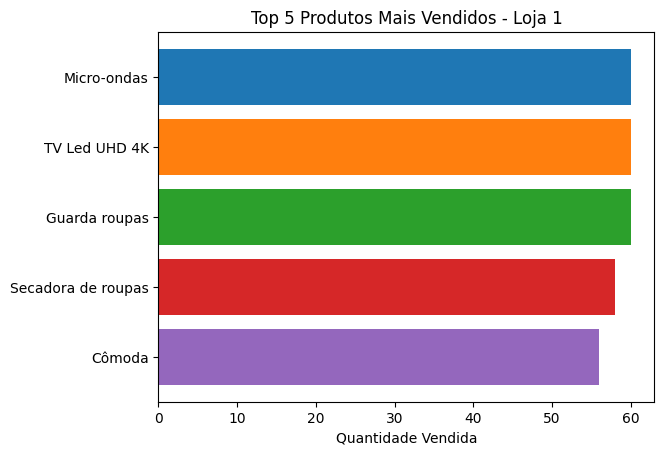

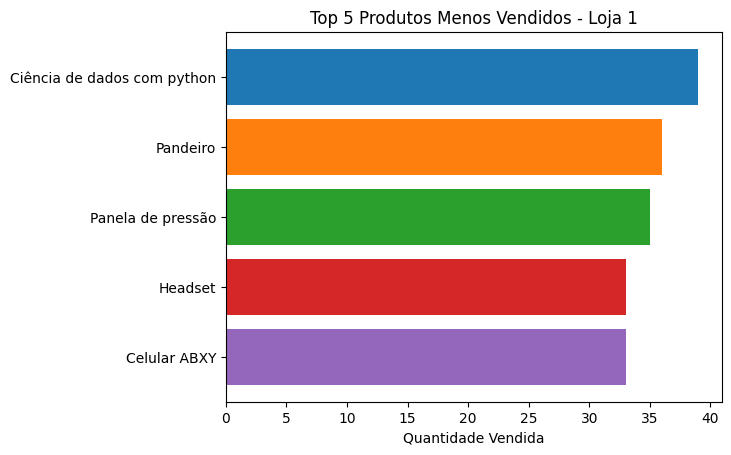

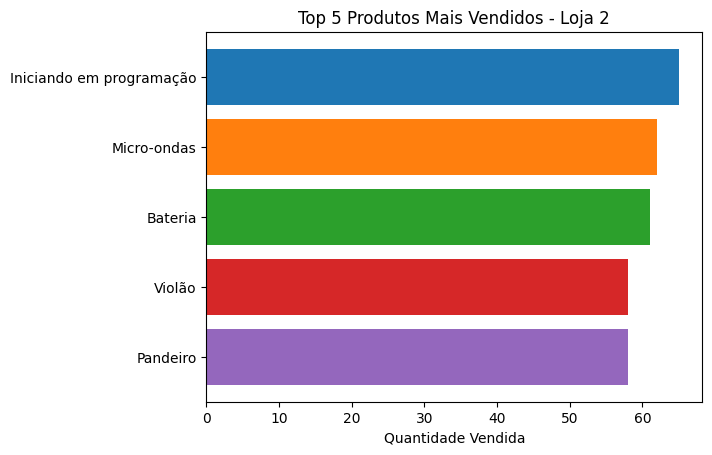

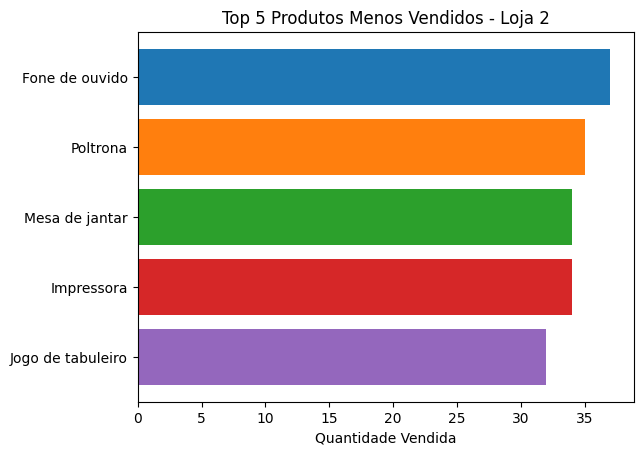

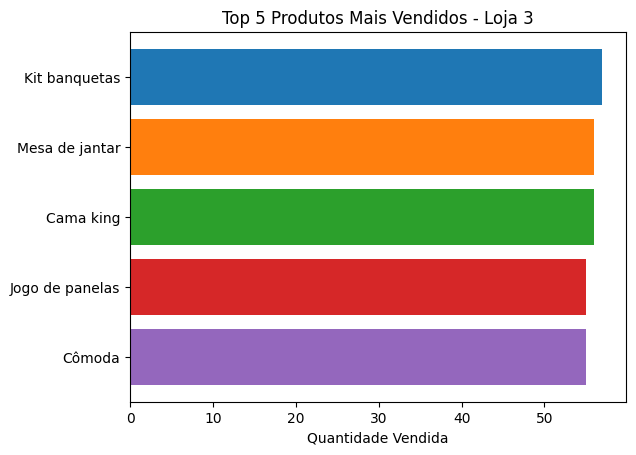

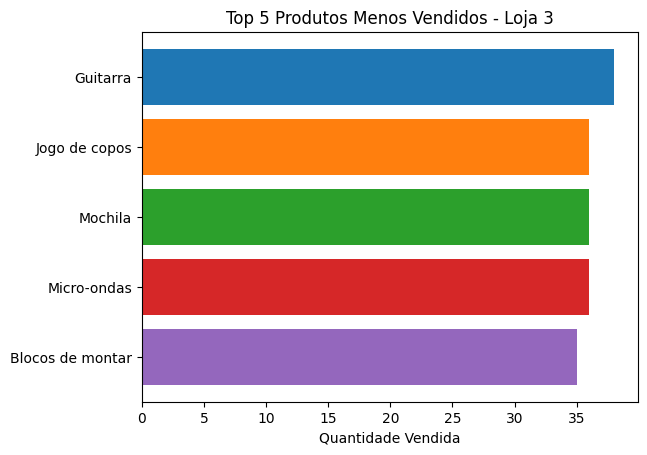

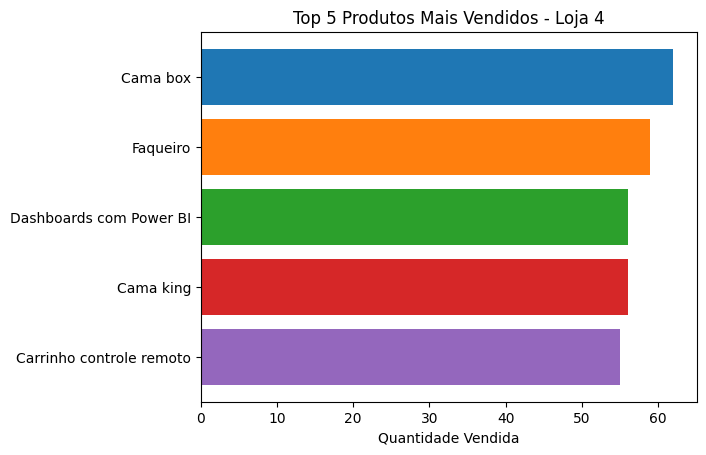

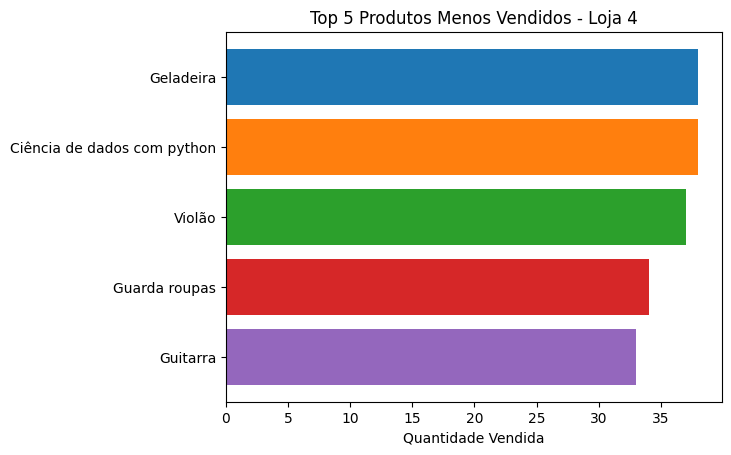

In [69]:
cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i in range(0,4):

    produtos_vendidos = lista_lojas[i]['Produto'].value_counts()

    top5 = produtos_vendidos.head(5)
    bottom5 = produtos_vendidos.tail(5)

    # mais vendidos
    plt.figure()

    plt.barh(top5.index, top5.values, color=cores)
    plt.xlabel("Quantidade Vendida")
    plt.title(f"Top 5 Produtos Mais Vendidos - Loja {i+1}")

    plt.gca().invert_yaxis()
    plt.show()

    # menos vendidos
    plt.figure()

    plt.barh(bottom5.index, bottom5.values, color=cores)
    plt.xlabel("Quantidade Vendida")
    plt.title(f"Top 5 Produtos Menos Vendidos - Loja {i+1}")

    plt.gca().invert_yaxis()
    plt.show()

# 5. Frete Médio por Loja

In [70]:
print("Frete médio por loja:")

for i in range(0,4):
  frete_medio = lista_lojas[i]['Frete'].mean()
  print(f"Loja {i+1}: R$ {frete_medio:.2f}")

Frete médio por loja:
Loja 1: R$ 34.69
Loja 2: R$ 33.62
Loja 3: R$ 33.07
Loja 4: R$ 31.28


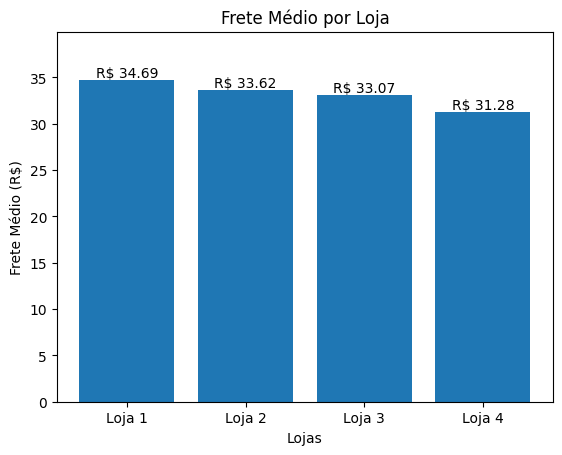

In [71]:
medias_frete = []
nomes_lojas = []

for i in range(0,4):
    frete_medio = lista_lojas[i]['Frete'].mean()
    medias_frete.append(frete_medio)
    nomes_lojas.append(f"Loja {i+1}")


plt.figure()
barras = plt.bar(nomes_lojas, medias_frete)
plt.bar_label(barras, fmt='R$ %.2f')
plt.ylabel("Frete Médio (R$)")
plt.xlabel("Lojas")
plt.title("Frete Médio por Loja")

plt.ylim(0, max(medias_frete) * 1.15)

plt.show()